# CASE STUDY

## Import Libraries

In [2965]:
# Import necessary libraries for data analysis, visualization, preprocessing, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
import seaborn as sns
import scipy.stats as stats
import pingouin as pg

## Data Cleaning

In [2966]:
# Load the Stata .dta file and display basic information about the dataset
df = pd.read_stata('LCF.dta')

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Column names:")
print(df.columns)
print("\nFirst few rows:")
df.head()

Dataset shape: 5144 rows, 19 columns

Column names:
Index(['casenew', 'weighta', 'P550tpr', 'P344pr', 'P425r', 'A172', 'A093r',
       'A094r', 'A121r', 'SexHRP', 'A049r', 'G018r', 'G019r', 'Gorx',
       'weightar', 'maininc', 'income', 'expenditure', 'hhsize'],
      dtype='str')

First few rows:


,casenew,weighta,P550tpr,P344pr,P425r,A172,A093r,A094r,A121r,SexHRP,A049r,G018r,G019r,Gorx,weightar,maininc,income,expenditure,hhsize
0,14999,2.834724,380.695762,465.36,Earned income,Yes,Economically inactive,Routine and manual occupations,Public rented,Female,4 person,2 adults,Two or more children,East Midlands,0.543248,earnings,465.359985,380.695770,4
1,14993,10.077947,546.413403,855.26,Earned income,Yes,Full-time working,"Never worked and long term unemployed, student...",Owned,Female,2 person,2 adults,No children,London,1.931344,earnings,855.260010,546.413391,2
2,14993,4.088676,242.189023,160.96,Earned income,Yes,Full-time working,Intermediate occupations,Owned,Female,1 person,1 adult,No children,South East,0.783557,earnings,160.960007,242.189026,1
3,14984,4.571760,421.382353,656.22,Earned income,Yes,Full-time working,Routine and manual occupations,Owned,Male,2 person,2 adults,No children,Eastern,0.876135,earnings,656.219971,421.382355,2
4,14981,7.349617,370.405577,398.80,Earned income,Yes,Full-time working,"Never worked and long term unemployed, student...",Owned,Male,1 person,1 adult,No children,South East,1.408485,earnings,398.799988,370.405579,1


In [2967]:
# Rename all columns to more descriptive names for better readability
df.columns = ['Case number', 'Annual weight', 'Total expenditure', 'Gross normal weekly household income - anonymised', 'Main source of household income - code', 'Internet connection in household', 'Economic position of household reference person', 'NS - SEC 8 Class of household reference person', 'Tenure type', 'Sex of household reference person', 'Number of persons in household', 'Number of adults', 'Number of children', 'Government Office Region modified', 'Annual weight r', 'Main income', 'Income', 'Expenditure', 'Household size']

df.head()

,Case number,Annual weight,Total expenditure,Gross normal weekly household income - anonymised,Main source of household income - code,Internet connection in household,Economic position of household reference person,NS - SEC 8 Class of household reference person,Tenure type,Sex of household reference person,Number of persons in household,Number of adults,Number of children,Government Office Region modified,Annual weight r,Main income,Income,Expenditure,Household size
0,14999,2.834724,380.695762,465.36,Earned income,Yes,Economically inactive,Routine and manual occupations,Public rented,Female,4 person,2 adults,Two or more children,East Midlands,0.543248,earnings,465.359985,380.695770,4
1,14993,10.077947,546.413403,855.26,Earned income,Yes,Full-time working,"Never worked and long term unemployed, student...",Owned,Female,2 person,2 adults,No children,London,1.931344,earnings,855.260010,546.413391,2
2,14993,4.088676,242.189023,160.96,Earned income,Yes,Full-time working,Intermediate occupations,Owned,Female,1 person,1 adult,No children,South East,0.783557,earnings,160.960007,242.189026,1
3,14984,4.571760,421.382353,656.22,Earned income,Yes,Full-time working,Routine and manual occupations,Owned,Male,2 person,2 adults,No children,Eastern,0.876135,earnings,656.219971,421.382355,2
4,14981,7.349617,370.405577,398.80,Earned income,Yes,Full-time working,"Never worked and long term unemployed, student...",Owned,Male,1 person,1 adult,No children,South East,1.408485,earnings,398.799988,370.405579,1


In [2968]:
# Display summary statistics for all columns in the dataset
df.describe(include="all")

,Case number,Annual weight,Total expenditure,Gross normal weekly household income - anonymised,Main source of household income - code,Internet connection in household,Economic position of household reference person,NS - SEC 8 Class of household reference person,Tenure type,Sex of household reference person,Number of persons in household,Number of adults,Number of children,Government Office Region modified,Annual weight r,Main income,Income,Expenditure,Household size
count,5144.000000,5144.000000,5144.000000,5144.000000,5144,5144,5144,5144,5144,5144,5144,5144,5144,5144,5144.000000,5144,5144.000000,5144.000000,5144.000000
unique,NaN,NaN,NaN,NaN,2,2,4,5,3,2,5,4,3,12,NaN,2,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,Earned income,Yes,Full-time working,Not classified for other reasons,Owned,Male,2 person,2 adults,No children,South East,NaN,earnings,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,2841,4232,2440,1619,3466,3156,1926,2826,3605,681,NaN,2841,NaN,NaN,NaN
mean,7487.702372,5.218090,479.758419,620.433572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.999998,NaN,620.433594,479.758423,2.328538
std,4309.792247,1.783115,292.365225,359.155682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.341717,NaN,359.155670,292.365234,1.195686
min,1.000000,0.001000,30.525000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000192,NaN,0.000000,30.525000,1.000000
25%,3716.750000,4.088583,254.127817,314.101875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.783539,NaN,314.101868,254.127823,1.000000
50%,7509.500000,4.919582,419.903451,563.150000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.942792,NaN,563.149994,419.903442,2.000000
75%,11204.500000,5.967865,644.974426,928.035500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.143685,NaN,928.035507,644.974411,3.000000


In [2969]:
# Check the data types of all columns
df.dtypes

Case number                                             int16
Annual weight                                         float64
Total expenditure                                     float64
Gross normal weekly household income - anonymised     float64
Main source of household income - code               category
Internet connection in household                     category
Economic position of household reference person      category
NS - SEC 8 Class of household reference person       category
Tenure type                                          category
Sex of household reference person                    category
Number of persons in household                       category
Number of adults                                     category
Number of children                                   category
Government Office Region modified                    category
Annual weight r                                       float64
Main income                                          category
Income  

In [2970]:
#Check for duplicate case numbers and the overall dataset to ensure data integrity
print(df['Case number'].duplicated().sum())

print(df.duplicated().sum())

782
0


In [2971]:
# Check for missing values (null and NaN) in the dataset
print(df.isnull().sum())

print(df.isna().sum())

Case number                                          0
Annual weight                                        0
Total expenditure                                    0
Gross normal weekly household income - anonymised    0
Main source of household income - code               0
Internet connection in household                     0
Economic position of household reference person      0
NS - SEC 8 Class of household reference person       0
Tenure type                                          0
Sex of household reference person                    0
Number of persons in household                       0
Number of adults                                     0
Number of children                                   0
Government Office Region modified                    0
Annual weight r                                      0
Main income                                          0
Income                                               0
Expenditure                                          0
Household 

In [2972]:
# Export the cleaned dataframe to CSV for future use
df.to_csv('cleaned_df.csv', index=False)

## Individual Independent Variable Analyses

### Tenure Type

#### Distribution and Count

In [2973]:
# Check the unique values in the 'Tenure type' column
df['Tenure type'].unique()

['Public rented', 'Owned', 'Private rented']
Categories (3, str): ['Public rented' < 'Private rented' < 'Owned']

Owned: 3466 (67.38%)
Public rented: 880 (17.11%)
Private rented: 798 (15.51%)
Total: 5144 (100.0%)


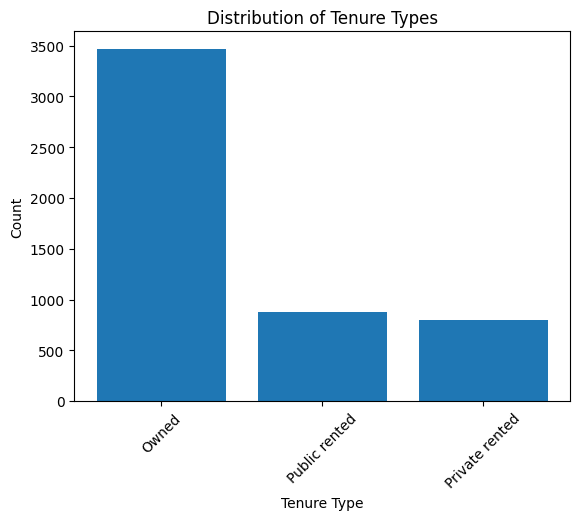

In [2974]:
# Calculate and print the count and percentage of each tenure type in the dataset
print("Owned: " + str(df['Tenure type'][df['Tenure type']=='Owned'].count()) + " (" + str(round(df['Tenure type'][df['Tenure type']=='Owned'].count() / df['Tenure type'].count() * 100, 2)) + "%)")
print("Public rented: " + str(df['Tenure type'][df['Tenure type']=='Public rented'].count()) + " (" + str(round(df['Tenure type'][df['Tenure type']=='Public rented'].count() / df['Tenure type'].count() * 100, 2)) + "%)")
print("Private rented: " + str(df['Tenure type'][df['Tenure type']=='Private rented'].count()) + " (" + str(round(df['Tenure type'][df['Tenure type']=='Private rented'].count() / df['Tenure type'].count() * 100, 2)) + "%)")
print("Total: " + str(df['Tenure type'].count()) + " (100.0%)")


tenure_counts = df['Tenure type'].value_counts()
plt.bar(tenure_counts.index, tenure_counts.values)
plt.xlabel('Tenure Type')
plt.ylabel('Count')
plt.title('Distribution of Tenure Types')
plt.xticks(rotation=45)
plt.show()

#### Summary Statistics

In [2975]:
# Calculate and print the mean, standard deviation, count, minimum, and maximum expenditure for each tenure type
expenditure_by_tenure = df.groupby('Tenure type')['Expenditure'].agg(['mean', 'std', 'count','min','max'])
print(expenditure_by_tenure)

                      mean         std  count     min     max
Tenure type                                                  
Public rented   284.933319  187.023468    880  30.525  1175.0
Private rented  472.386383  275.716125    798  31.952  1175.0
Owned           530.920837  297.056030   3466  32.355  1175.0


#### Outlier Check

<Figure size 1000x600 with 0 Axes>

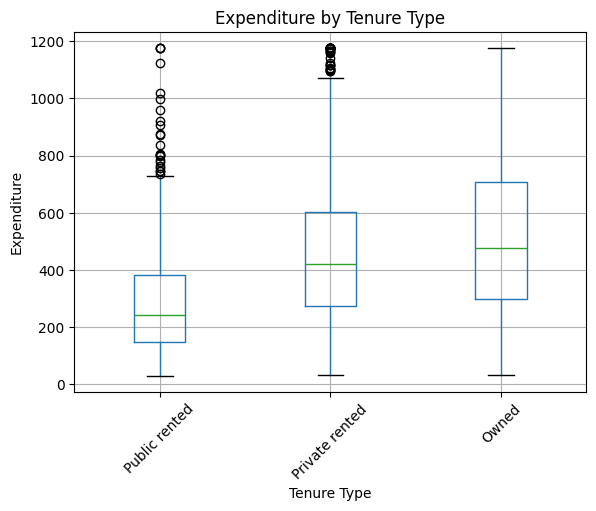

Outliers present in the Public rented and Private rented groups, but not in the Owned group


In [2976]:
# Check outliers in expenditure across tenure types using boxplots
plt.figure(figsize=(10, 6))
df.boxplot(column='Expenditure', by='Tenure type')
plt.xlabel('Tenure Type')
plt.ylabel('Expenditure')
plt.title('Expenditure by Tenure Type')
plt.suptitle('')
plt.xticks(rotation=45)
plt.show()

print("Outliers present in the Public rented and Private rented groups, but not in the Owned group")

#### Normality Check

In [2977]:
# Check the normality of expenditure within each tenure type using the Shapiro-Wilk test
for tenure in df['Tenure type'].unique():
    tenure_data = df[df['Tenure type'] == tenure]['Expenditure'].dropna()
    stat, p = stats.shapiro(tenure_data)
    print(f'Shapiro-Wilk test for {tenure}: W={stat:.4f}, p={p:.4f}')

print("\nThe expenditure is not normally distributed within each group")

Shapiro-Wilk test for Public rented: W=0.8994, p=0.0000
Shapiro-Wilk test for Owned: W=0.9374, p=0.0000
Shapiro-Wilk test for Private rented: W=0.9175, p=0.0000

The expenditure is not normally distributed within each group


#### Homogeneity of Variances

In [2978]:
# Check the homogeneity of variances across tenure types using Levene's test
levene_stat, levene_p = stats.levene(df['Expenditure'][df['Tenure type'] == 'Owned'], df['Expenditure'][df['Tenure type'] == 'Public rented'], df['Expenditure'][df['Tenure type'] == 'Private rented'])
print(f"Levene's test statistic: {levene_stat:.4f}, p-value: {levene_p:.4f}")

print("\nThe variance is heterogeneous between the groups")

Levene's test statistic: 107.5093, p-value: 0.0000

The variance is heterogeneous between the groups


#### Welch-ANOVA Test

In [2979]:
# Perform Welch ANOVA test to compare expenditure across all tenure types
print("\nThe ANOVA assumptions are violated, therefore using Welch-ANOVA test instead")

welch_anova_result = pg.welch_anova(dv='Expenditure', between='Tenure type', data=df)
print("\nWelch ANOVA Test Results:")
print(welch_anova_result)
print(f"\nF-statistic: {welch_anova_result['F'].values[0]:.4f}")
print(f"p-value: {welch_anova_result['p-unc'].values[0]:.4f}")

print("\nThere is a statistically significant difference in expenditure across tenure types")


The ANOVA assumptions are violated, therefore using Welch-ANOVA test instead

Welch ANOVA Test Results:
        Source  ddof1        ddof2           F          p-unc       np2
0  Tenure type      2  1783.592873  470.158022  1.003325e-164  0.096717

F-statistic: 470.1580
p-value: 0.0000

There is a statistically significant difference in expenditure across tenure types


#### Kruskal-Wallis Test

In [2980]:
# Check the robustness of the Welch ANOVA results using the non-parametric Kruskal-Wallis test
kruskal_stat, kruskal_p = stats.kruskal(df['Expenditure'][df['Tenure type'] == 'Owned'], df['Expenditure'][df['Tenure type'] == 'Public rented'], df['Expenditure'][df['Tenure type'] == 'Private rented'])
print(f"Kruskal-Wallis test statistic: {kruskal_stat:.4f}, p-value: {kruskal_p:.4f}")
print("\nKruskal-Wallis test confirms the Welch ANOVA results")

Kruskal-Wallis test statistic: 589.5717, p-value: 0.0000

Kruskal-Wallis test confirms the Welch ANOVA results


### Occupational Class

#### Distribution and Count

In [2981]:
# Check the unique values in the 'Occupation class' column
df['NS - SEC 8 Class of household reference person'].unique()

['Routine and manual occupations', 'Never worked and long term unemployed, studen..., 'Intermediate occupations', 'Not classified for other reasons', 'Higher managerial, administrative and profess...]
Categories (5, str): ['Higher managerial, administrative and profess... < 'Intermediate occupations' < 'Routine and manual occupations' < 'Never worked and long term unemployed, studen... < 'Not classified for other reasons']

Routine and manual occupations: 1045 (20.31%)
Never worked and long term unemployed, students and occupation not stated: 200 (3.89%)
Intermediate occupations: 691 (13.43%)
Not classified for other reasons: 1619 (31.47%)
Higher managerial, administrative and professional occupations: 1589 (30.89%)
Total: 5144 (100.0%)


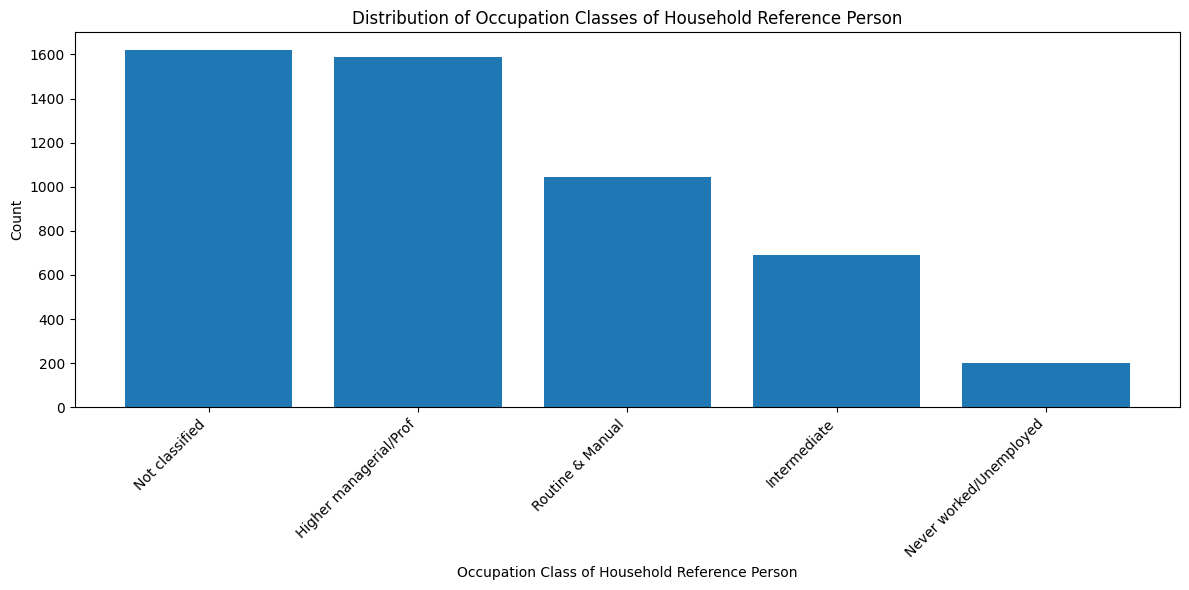

In [2982]:
# Calculate and print the count and percentage of each occupation class in the dataset
print("Routine and manual occupations: " + str(df['NS - SEC 8 Class of household reference person'][df['NS - SEC 8 Class of household reference person']=='Routine and manual occupations'].count()) + " (" + str(round(df['NS - SEC 8 Class of household reference person'][df['NS - SEC 8 Class of household reference person']=='Routine and manual occupations'].count() / df['NS - SEC 8 Class of household reference person'].count() * 100, 2)) + "%)")
print("Never worked and long term unemployed, students and occupation not stated: " + str(df['NS - SEC 8 Class of household reference person'][df['NS - SEC 8 Class of household reference person']=='Never worked and long term unemployed, students and occupation not stated'].count()) + " (" + str(round(df['NS - SEC 8 Class of household reference person'][df['NS - SEC 8 Class of household reference person']=='Never worked and long term unemployed, students and occupation not stated'].count() / df['NS - SEC 8 Class of household reference person'].count() * 100, 2)) + "%)")
print("Intermediate occupations: " + str(df['NS - SEC 8 Class of household reference person'][df['NS - SEC 8 Class of household reference person']=='Intermediate occupations'].count()) + " (" + str(round(df['NS - SEC 8 Class of household reference person'][df['NS - SEC 8 Class of household reference person']=='Intermediate occupations'].count() / df['NS - SEC 8 Class of household reference person'].count() * 100, 2)) + "%)")
print("Not classified for other reasons: " + str(df['NS - SEC 8 Class of household reference person'][df['NS - SEC 8 Class of household reference person']=='Not classified for other reasons'].count()) + " (" + str(round(df['NS - SEC 8 Class of household reference person'][df['NS - SEC 8 Class of household reference person']=='Not classified for other reasons'].count() / df['NS - SEC 8 Class of household reference person'].count() * 100, 2)) + "%)")
print("Higher managerial, administrative and professional occupations: " + str(df['NS - SEC 8 Class of household reference person'][df['NS - SEC 8 Class of household reference person']=='Higher managerial, administrative and professional occupations'].count()) + " (" + str(round(df['NS - SEC 8 Class of household reference person'][df['NS - SEC 8 Class of household reference person']=='Higher managerial, administrative and professional occupations'].count() / df['NS - SEC 8 Class of household reference person'].count() * 100, 2)) + "%)")
print("Total: " + str(df['NS - SEC 8 Class of household reference person'].count()) + " (100.0%)")

# Create abbreviations for occupation classes
abbrev_mapping = {
    'Routine and manual occupations': 'Routine & Manual',
    'Never worked and long term unemployed, students and occupation not stated': 'Never worked/Unemployed',
    'Intermediate occupations': 'Intermediate',
    'Not classified for other reasons': 'Not classified',
    'Higher managerial, administrative and professional occupations': 'Higher managerial/Prof'
}

occupation_counts = df['NS - SEC 8 Class of household reference person'].value_counts()
occupation_counts.index = occupation_counts.index.map(abbrev_mapping)

plt.figure(figsize=(12, 6))
plt.bar(occupation_counts.index, occupation_counts.values)
plt.xlabel('Occupation Class of Household Reference Person')
plt.ylabel('Count')
plt.title('Distribution of Occupation Classes of Household Reference Person')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Summary Statistics

In [2983]:
# Calculate and print the mean, standard deviation, count, minimum, and maximum expenditure for each occupation class
expenditure_by_occupation = df.groupby('NS - SEC 8 Class of household reference person')['Expenditure'].agg(['mean', 'std', 'count','min','max'])
print(expenditure_by_occupation)

                                                          mean         std  \
NS - SEC 8 Class of household reference person                               
Higher managerial, administrative and professio...  664.518005  286.855530   
Intermediate occupations                            501.059113  262.646912   
Routine and manual occupations                      420.954071  228.916809   
Never worked and long term unemployed, students...  349.267761  293.214172   
Not classified for other reasons                    343.406921  245.917267   

                                                    count        min     max  
NS - SEC 8 Class of household reference person                                
Higher managerial, administrative and professio...   1589  58.020000  1175.0  
Intermediate occupations                              691  31.952000  1175.0  
Routine and manual occupations                       1045  37.276608  1175.0  
Never worked and long term unemployed, students...    200 

#### Outlier Check

<Figure size 1200x600 with 0 Axes>

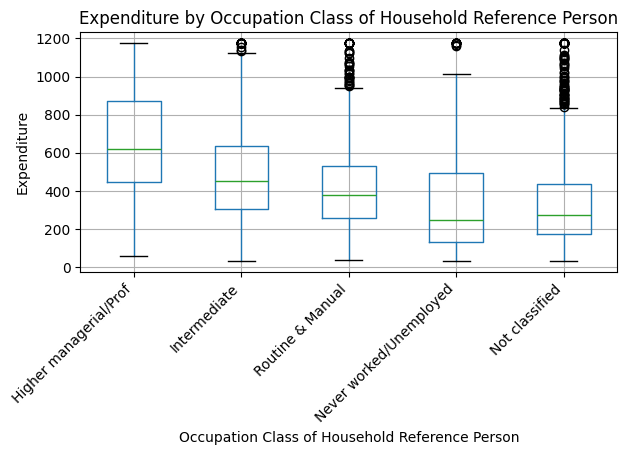

Outliers present in all the occupation classes, except Higher managerial/Prof


In [2984]:
# Check outliers in expenditure across occupational class using boxplots
# Create abbreviations for occupation classes
abbrev_mapping = {
    'Routine and manual occupations': 'Routine & Manual',
    'Never worked and long term unemployed, students and occupation not stated': 'Never worked/Unemployed',
    'Intermediate occupations': 'Intermediate',
    'Not classified for other reasons': 'Not classified',
    'Higher managerial, administrative and professional occupations': 'Higher managerial/Prof'
}

# Create a temporary dataframe with abbreviated occupation class labels
df_plot = df.copy()
df_plot['NS - SEC 8 Class of household reference person'] = df_plot['NS - SEC 8 Class of household reference person'].map(abbrev_mapping)

plt.figure(figsize=(12, 6))
df_plot.boxplot(column='Expenditure', by='NS - SEC 8 Class of household reference person')
plt.xlabel('Occupation Class of Household Reference Person')
plt.ylabel('Expenditure')
plt.title('Expenditure by Occupation Class of Household Reference Person')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Outliers present in all the occupation classes, except Higher managerial/Prof")

#### Normality Check

In [2985]:
# Check the normality of expenditure within each occupational class using the Shapiro-Wilk test
for occupation in df['NS - SEC 8 Class of household reference person'].unique():
    occupation_data = df[df['NS - SEC 8 Class of household reference person'] == occupation]['Expenditure'].dropna()
    stat, p = stats.shapiro(occupation_data)
    print(f'Shapiro-Wilk test for {occupation}: W={stat:.4f}, p={p:.4f}')
print("\nThe expenditure is not normally distributed within each group")

Shapiro-Wilk test for Routine and manual occupations: W=0.9305, p=0.0000
Shapiro-Wilk test for Never worked and long term unemployed, students and occupation not stated: W=0.8357, p=0.0000
Shapiro-Wilk test for Intermediate occupations: W=0.9319, p=0.0000
Shapiro-Wilk test for Not classified for other reasons: W=0.8489, p=0.0000
Shapiro-Wilk test for Higher managerial, administrative and professional occupations: W=0.9522, p=0.0000

The expenditure is not normally distributed within each group


#### Homogeneity of Variances

In [2986]:
# Check the homogeneity of variances across occupational classes using Levene's test
levene_stat, levene_p = stats.levene(df['Expenditure'][df['NS - SEC 8 Class of household reference person'] == 'Routine and manual occupations'], df['Expenditure'][df['NS - SEC 8 Class of household reference person'] == 'Never worked and long term unemployed, students and occupation not stated'], df['Expenditure'][df['NS - SEC 8 Class of household reference person'] == 'Intermediate occupations'], df['Expenditure'][df['NS - SEC 8 Class of household reference person'] == 'Not classified for other reasons'], df['Expenditure'][df['NS - SEC 8 Class of household reference person'] == 'Higher managerial, administrative and professional occupations'])
print(f"Levene's test statistic: {levene_stat:.4f}, p-value: {levene_p:.4f}")

print("\nThe variance is heterogeneous between the groups")

Levene's test statistic: 32.6230, p-value: 0.0000

The variance is heterogeneous between the groups


#### Welch-ANOVA Test

In [2987]:
# Perform Welch ANOVA test to compare expenditure across all occupational classes
print("\nThe ANOVA assumptions are violated, therefore using Welch-ANOVA test instead")

welch_anova_result = pg.welch_anova(dv='Expenditure', between='NS - SEC 8 Class of household reference person', data=df)
print("\nWelch ANOVA Test Results:")
print(welch_anova_result)
print(f"\nF-statistic: {welch_anova_result['F'].values[0]:.4f}")
print(f"p-value: {welch_anova_result['p-unc'].values[0]:.4f}")

print("\nThere is a statistically significant difference in expenditure across occupational classes")


The ANOVA assumptions are violated, therefore using Welch-ANOVA test instead

Welch ANOVA Test Results:
                                           Source  ddof1        ddof2  \
0  NS - SEC 8 Class of household reference person      4  1144.231476   

           F          p-unc       np2  
0  311.18947  3.717250e-181  0.208537  

F-statistic: 311.1895
p-value: 0.0000

There is a statistically significant difference in expenditure across occupational classes


#### Kruskal-Wallis Test

In [2988]:
# Check the robustness of the Welch ANOVA results using the non-parametric Kruskal-Wallis test
kruskal_stat, kruskal_p = stats.kruskal(df['Expenditure'][df['Tenure type'] == 'Owned'], df['Expenditure'][df['Tenure type'] == 'Public rented'], df['Expenditure'][df['Tenure type'] == 'Private rented'])
print(f"Kruskal-Wallis test statistic: {kruskal_stat:.4f}, p-value: {kruskal_p:.4f}")
print("\nKruskal-Wallis test confirms the Welch ANOVA results")

Kruskal-Wallis test statistic: 589.5717, p-value: 0.0000

Kruskal-Wallis test confirms the Welch ANOVA results


### Number of Adults

#### Distribution and Count

In [2989]:
# Check the unique values in the 'Number of adults' column
df['Number of adults'].unique()

['2 adults', '1 adult', '4 and more adults', '3 adults']
Categories (4, str): ['1 adult' < '2 adults' < '3 adults' < '4 and more adults']

1 adult: 1729 (33.61%)
2 adults: 2826 (54.94%)
3 adults: 422 (8.2%)
4 and more adults: 167 (3.25%)
Total: 5144 (100.0%)


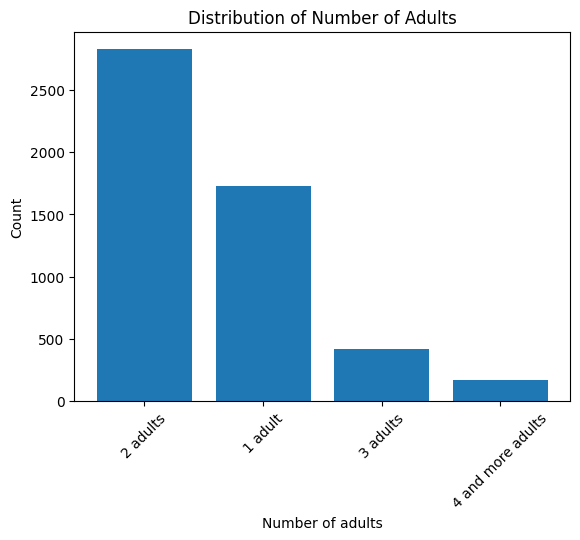

In [2990]:
# Calculate and print the count and percentage of each 'Number of adults' in the dataset
print("1 adult: " + str(df['Number of adults'][df['Number of adults']=='1 adult'].count()) + " (" + str(round(df['Number of adults'][df['Number of adults']=='1 adult'].count() / df['Number of adults'].count() * 100, 2)) + "%)")
print("2 adults: " + str(df['Number of adults'][df['Number of adults']=='2 adults'].count()) + " (" + str(round(df['Number of adults'][df['Number of adults']=='2 adults'].count() / df['Number of adults'].count() * 100, 2)) + "%)")
print("3 adults: " + str(df['Number of adults'][df['Number of adults']=='3 adults'].count()) + " (" + str(round(df['Number of adults'][df['Number of adults']=='3 adults'].count() / df['Number of adults'].count() * 100, 2)) + "%)")
print("4 and more adults: " + str(df['Number of adults'][df['Number of adults']=='4 and more adults'].count()) + " (" + str(round(df['Number of adults'][df['Number of adults']=='4 and more adults'].count() / df['Number of adults'].count() * 100, 2)) + "%)")
print("Total: " + str(df['Number of adults'].count()) + " (100.0%)")

adult_counts = df['Number of adults'].value_counts()
plt.bar(adult_counts.index, adult_counts.values)
plt.xlabel('Number of adults')
plt.ylabel('Count')
plt.title('Distribution of Number of Adults')
plt.xticks(rotation=45)
plt.show()

#### Summary Statistics

In [2991]:
# Calculate and print the mean, standard deviation, count, minimum, and maximum expenditure by number of adults
expenditure_by_adults = df.groupby('Number of adults')['Expenditure'].agg(['mean', 'std', 'count','min','max'])
print(expenditure_by_adults)

                         mean         std  count         min     max
Number of adults                                                    
1 adult            285.468842  196.881485   1729   30.525000  1175.0
2 adults           553.389221  275.385254   2826   61.689999  1175.0
3 adults           674.806946  289.663971    422   82.730003  1175.0
4 and more adults  752.426147  290.477325    167  183.816711  1175.0


#### Outlier Check

<Figure size 1000x600 with 0 Axes>

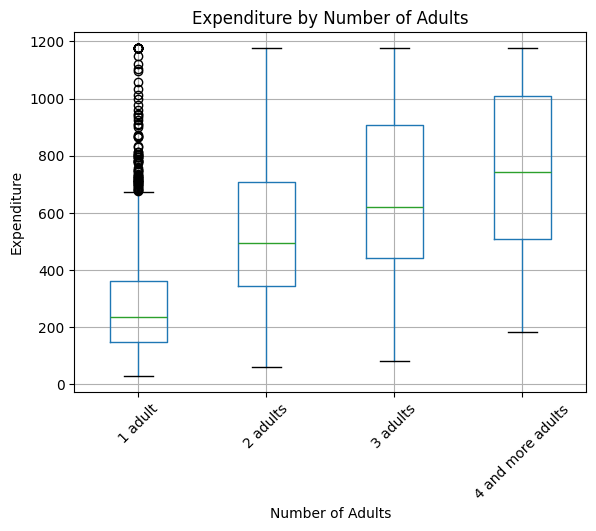

Outliers present in 1 Adult group, but not in the rest of the groups


In [2992]:
# Check outliers in expenditure across adults using boxplots
plt.figure(figsize=(10, 6))
df.boxplot(column='Expenditure', by='Number of adults')
plt.xlabel('Number of Adults')
plt.ylabel('Expenditure')
plt.title('Expenditure by Number of Adults')
plt.suptitle('')
plt.xticks(rotation=45)
plt.show()

print("Outliers present in 1 Adult group, but not in the rest of the groups")

#### Normality Check

In [2993]:
# Check the normality of expenditure within number of adults using the Shapiro-Wilk test
for tenure in df['Number of adults'].unique():
    tenure_data = df[df['Number of adults'] == tenure]['Expenditure'].dropna()
    stat, p = stats.shapiro(tenure_data)
    print(f'Shapiro-Wilk test for {tenure}: W={stat:.4f}, p={p:.4f}')

print("\nThe expenditure is not normally distributed within each group")

Shapiro-Wilk test for 2 adults: W=0.9358, p=0.0000
Shapiro-Wilk test for 1 adult: W=0.8506, p=0.0000
Shapiro-Wilk test for 4 and more adults: W=0.9398, p=0.0000
Shapiro-Wilk test for 3 adults: W=0.9411, p=0.0000

The expenditure is not normally distributed within each group


#### Homogeneity of Variances

In [2994]:
# Check the homogeneity of variances across the number of adults using Levene's test
levene_stat, levene_p = stats.levene(df['Expenditure'][df['Number of adults'] == '1 adult'], df['Expenditure'][df['Number of adults'] == '2 adults'], df['Expenditure'][df['Number of adults'] == '3 adults'], df['Expenditure'][df['Number of adults'] == '4 and more adults'])
print(f"Levene's test statistic: {levene_stat:.4f}, p-value: {levene_p:.4f}")

print("\nThe variance is heterogeneous between the groups")

Levene's test statistic: 95.5784, p-value: 0.0000

The variance is heterogeneous between the groups


#### Welch-ANOVA Test

In [2995]:
# Perform Welch ANOVA test to compare expenditure across all tenure types
print("\nThe ANOVA assumptions are violated, therefore using Welch-ANOVA test instead")

welch_anova_result = pg.welch_anova(dv='Expenditure', between='Number of adults', data=df)
print("\nWelch ANOVA Test Results:")
print(welch_anova_result)
print(f"\nF-statistic: {welch_anova_result['F'].values[0]:.4f}")
print(f"p-value: {welch_anova_result['p-unc'].values[0]:.4f}")

print("\nThere is a statistically significant difference in expenditure across the number of adults")


The ANOVA assumptions are violated, therefore using Welch-ANOVA test instead

Welch ANOVA Test Results:
             Source  ddof1      ddof2           F          p-unc       np2
0  Number of adults      3  614.56524  667.313251  8.144704e-193  0.248081

F-statistic: 667.3133
p-value: 0.0000

There is a statistically significant difference in expenditure across the number of adults


#### Kruskal-Wallis Test

In [2996]:
# Check the robustness of the Welch ANOVA results using the non-parametric Kruskal-Wallis test
kruskal_stat, kruskal_p = stats.kruskal(df['Expenditure'][df['Number of adults'] == '1 adult'], df['Expenditure'][df['Number of adults'] == '2 adults'], df['Expenditure'][df['Number of adults'] == '3 adults'], df['Expenditure'][df['Number of adults'] == '4 and more adults'])
print(f"Kruskal-Wallis test statistic: {kruskal_stat:.4f}, p-value: {kruskal_p:.4f}")
print("\nKruskal-Wallis test confirms the Welch ANOVA results")

Kruskal-Wallis test statistic: 1541.1841, p-value: 0.0000

Kruskal-Wallis test confirms the Welch ANOVA results


### Number of Children

#### Distribution and Count

In [2997]:
# Check the unique values in the 'Number of children' column
df['Number of children'].unique()

['Two or more children', 'No children', 'One child']
Categories (3, str): ['No children' < 'One child' < 'Two or more children']

No children: 3605 (70.08%)
One child: 654 (12.71%)
Two or more children: 885 (17.2%)
Total: 5144 (100.0%)


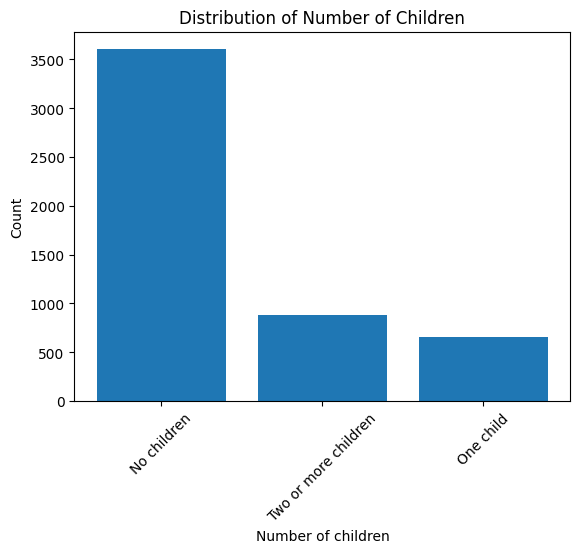

In [2998]:
# Calculate and print the count and percentage of number of children in the dataset
print("No children: " + str(df['Number of children'][df['Number of children']=='No children'].count()) + " (" + str(round(df['Number of children'][df['Number of children']=='No children'].count() / df['Number of children'].count() * 100, 2)) + "%)")
print("One child: " + str(df['Number of children'][df['Number of children']=='One child'].count()) + " (" + str(round(df['Number of children'][df['Number of children']=='One child'].count() / df['Number of children'].count() * 100, 2)) + "%)")
print("Two or more children: " + str(df['Number of children'][df['Number of children']=='Two or more children'].count()) + " (" + str(round(df['Number of children'][df['Number of children']=='Two or more children'].count() / df['Number of children'].count() * 100, 2)) + "%)")
print("Total: " + str(df['Number of children'].count()) + " (100.0%)")


children_counts = df['Number of children'].value_counts()
plt.bar(children_counts.index, children_counts.values)
plt.xlabel('Number of children')
plt.ylabel('Count')
plt.title('Distribution of Number of Children')
plt.xticks(rotation=45)
plt.show()

#### Summary Statistics

In [2999]:
# Calculate and print the mean, standard deviation, count, minimum, and maximum expenditure for number of children
expenditure_by_children = df.groupby('Number of children')['Expenditure'].agg(['mean', 'std', 'count','min','max'])
print(expenditure_by_children)

                            mean         std  count        min     max
Number of children                                                    
No children           436.051178  281.452179   3605  30.525000  1175.0
One child             552.422058  294.336334    654  57.705002  1175.0
Two or more children  604.100220  288.394958    885  61.689999  1175.0


#### Outlier Check

<Figure size 1000x600 with 0 Axes>

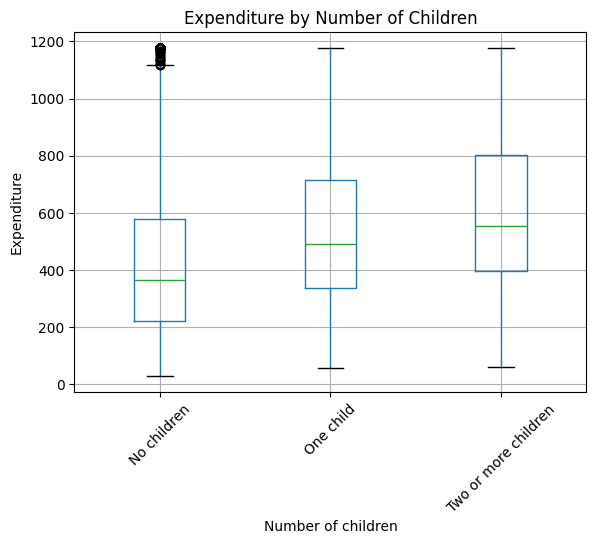

Outliers present in no children group, but not in the other groups


In [3000]:
# Check outliers in expenditure across number of children using boxplots
plt.figure(figsize=(10, 6))
df.boxplot(column='Expenditure', by='Number of children')
plt.xlabel('Number of children')
plt.ylabel('Expenditure')
plt.title('Expenditure by Number of Children')
plt.suptitle('')
plt.xticks(rotation=45)
plt.show()

print("Outliers present in no children group, but not in the other groups")

#### Normality Check

In [3001]:
# Check the normality of expenditure within number of children using the Shapiro-Wilk test
for tenure in df['Number of children'].unique():
    tenure_data = df[df['Number of children'] == tenure]['Expenditure'].dropna()
    stat, p = stats.shapiro(tenure_data)
    print(f'Shapiro-Wilk test for {tenure}: W={stat:.4f}, p={p:.4f}')

print("\nThe expenditure is not normally distributed within each group")

Shapiro-Wilk test for Two or more children: W=0.9543, p=0.0000
Shapiro-Wilk test for No children: W=0.9093, p=0.0000
Shapiro-Wilk test for One child: W=0.9350, p=0.0000

The expenditure is not normally distributed within each group


#### Homogeneity of Variances

In [3002]:
# Check the homogeneity of variances across number of children using Levene's test
levene_stat, levene_p = stats.levene(df['Expenditure'][df['Number of children'] == 'No children'], df['Expenditure'][df['Number of children'] == 'One child'], df['Expenditure'][df['Number of children'] == 'Two or more children'])
print(f"Levene's test statistic: {levene_stat:.4f}, p-value: {levene_p:.4f}")

print("\nThe variance is heterogeneous between the groups")

Levene's test statistic: 4.2401, p-value: 0.0145

The variance is heterogeneous between the groups


#### Welch-ANOVA Test

In [3003]:
# Perform Welch ANOVA test to compare expenditure across number of children
print("\nThe ANOVA assumptions are violated, therefore using Welch-ANOVA test instead")

welch_anova_result = pg.welch_anova(dv='Expenditure', between='Number of children', data=df)
print("\nWelch ANOVA Test Results:")
print(welch_anova_result)
print(f"\nF-statistic: {welch_anova_result['F'].values[0]:.4f}")
print(f"p-value: {welch_anova_result['p-unc'].values[0]:.4f}")

print("\nThere is a statistically significant difference in expenditure across the number of children")


The ANOVA assumptions are violated, therefore using Welch-ANOVA test instead

Welch ANOVA Test Results:
               Source  ddof1        ddof2           F         p-unc       np2
0  Number of children      2  1335.064616  145.473664  6.997109e-58  0.054645

F-statistic: 145.4737
p-value: 0.0000

There is a statistically significant difference in expenditure across the number of children


#### Kruskal-Wallis Test

In [3004]:
# Check the robustness of the Welch ANOVA results using the non-parametric Kruskal-Wallis test
kruskal_stat, kruskal_p = stats.kruskal(df['Expenditure'][df['Number of children'] == 'No children'], df['Expenditure'][df['Number of children'] == 'One child'], df['Expenditure'][df['Number of children'] == 'Two or more children'])
print(f"Kruskal-Wallis test statistic: {kruskal_stat:.4f}, p-value: {kruskal_p:.4f}")
print("\nKruskal-Wallis test confirms the Welch ANOVA results")

Kruskal-Wallis test statistic: 327.9272, p-value: 0.0000

Kruskal-Wallis test confirms the Welch ANOVA results


## Data Preprocessing

In [3013]:
# Display first 10 rows of the dataset
df.head(10)

,Case number,Annual weight,Total expenditure,Gross normal weekly household income - anonymised,Main source of household income - code,Internet connection in household,Economic position of household reference person,NS - SEC 8 Class of household reference person,Tenure type,Sex of household reference person,Number of persons in household,Number of adults,Number of children,Government Office Region modified,Annual weight r,Main income,Income,Expenditure,Household size
0,14999,2.834724,380.695762,465.3600,Earned income,Yes,Economically inactive,Routine and manual occupations,Public rented,Female,4 person,2 adults,Two or more children,East Midlands,0.543248,earnings,465.359985,380.695770,4
1,14993,10.077947,546.413403,855.2600,Earned income,Yes,Full-time working,"Never worked and long term unemployed, student...",Owned,Female,2 person,2 adults,No children,London,1.931344,earnings,855.260010,546.413391,2
2,14993,4.088676,242.189023,160.9600,Earned income,Yes,Full-time working,Intermediate occupations,Owned,Female,1 person,1 adult,No children,South East,0.783557,earnings,160.960007,242.189026,1
3,14984,4.571760,421.382353,656.2200,Earned income,Yes,Full-time working,Routine and manual occupations,Owned,Male,2 person,2 adults,No children,Eastern,0.876135,earnings,656.219971,421.382355,2
4,14981,7.349617,370.405577,398.8000,Earned income,Yes,Full-time working,"Never worked and long term unemployed, student...",Owned,Male,1 person,1 adult,No children,South East,1.408485,earnings,398.799988,370.405579,1
5,14976,5.046701,172.397164,321.0200,Earned income,No,Full-time working,Routine and manual occupations,Public rented,Male,1 person,1 adult,No children,Scotland,0.967153,earnings,321.019989,172.397171,1
6,14975,2.775957,202.425000,350.8340,Other income,Yes,Economically inactive,Not classified for other reasons,Owned,Male,2 person,2 adults,No children,Northern Ireland,0.531986,other source,350.834015,202.425003,2
7,14972,11.882653,730.658040,1184.9900,Earned income,Yes,Economically inactive,Not classified for other reasons,Public rented,Female,5 person or more,4 and more adults,No children,South East,2.277199,earnings,1184.989990,730.658020,5
8,14971,6.068373,361.930965,619.5700,Earned income,Yes,Full-time working,Intermediate occupations,Owned,Male,2 person,2 adults,No children,Wales,1.162947,earnings,619.570007,361.930969,2
9,14970,5.090615,659.911689,1117.8415,Other income,Yes,Economically inactive,Not classified for other reasons,Owned,Male,2 person,2 adults,No children,Yorkshire and the Humber,0.975569,other source,1117.841553,659.911682,2


In [3014]:
# Check data types of all columns in the dataset
df.dtypes

Case number                                             int16
Annual weight                                         float64
Total expenditure                                     float64
Gross normal weekly household income - anonymised     float64
Main source of household income - code               category
Internet connection in household                     category
Economic position of household reference person      category
NS - SEC 8 Class of household reference person       category
Tenure type                                          category
Sex of household reference person                    category
Number of persons in household                       category
Number of adults                                     category
Number of children                                   category
Government Office Region modified                    category
Annual weight r                                       float64
Main income                                          category
Income  

In [3015]:
# Encode categorical variables using LabelEncoder
df_encoded = df.copy()
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['category']).columns

mappings = {}

for col in cat_cols:
    df_encoded[col] = df_encoded[col].astype(str)
    df_encoded[col] = le.fit_transform(df_encoded[col])
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f" -> {col}: {list(mapping.items())}")

 -> Main source of household income - code: [('Earned income', np.int64(0)), ('Other income', np.int64(1))]
 -> Internet connection in household: [('No', np.int64(0)), ('Yes', np.int64(1))]
 -> Economic position of household reference person: [('Economically inactive', np.int64(0)), ('Full-time working', np.int64(1)), ('Part-time working', np.int64(2)), ('Unemployed and work related Government Training Programmes', np.int64(3))]
 -> NS - SEC 8 Class of household reference person: [('Higher managerial, administrative and professional occupations', np.int64(0)), ('Intermediate occupations', np.int64(1)), ('Never worked and long term unemployed, students and occupation not stated', np.int64(2)), ('Not classified for other reasons', np.int64(3)), ('Routine and manual occupations', np.int64(4))]
 -> Tenure type: [('Owned', np.int64(0)), ('Private rented', np.int64(1)), ('Public rented', np.int64(2))]
 -> Sex of household reference person: [('Female', np.int64(0)), ('Male', np.int64(1))]
 ->

In [3016]:
# Scale all features to [0, 1] range using MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the encoded dataframe
df_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

print("Original df_encoded (first 5 rows):")
print(df_encoded.head())
print("\nScaled df_scaled (first 5 rows):")
print(df_scaled.head())
print("\nData type after scaling:")
print(df_scaled.dtypes)

Original df_encoded (first 5 rows):
   Case number  Annual weight  Total expenditure  \
0        14999       2.834724         380.695762   
1        14993      10.077947         546.413403   
2        14993       4.088676         242.189023   
3        14984       4.571760         421.382353   
4        14981       7.349617         370.405577   

   Gross normal weekly household income - anonymised  \
0                                             465.36   
1                                             855.26   
2                                             160.96   
3                                             656.22   
4                                             398.80   

   Main source of household income - code  Internet connection in household  \
0                                       0                                 1   
1                                       0                                 1   
2                                       0                                 1  

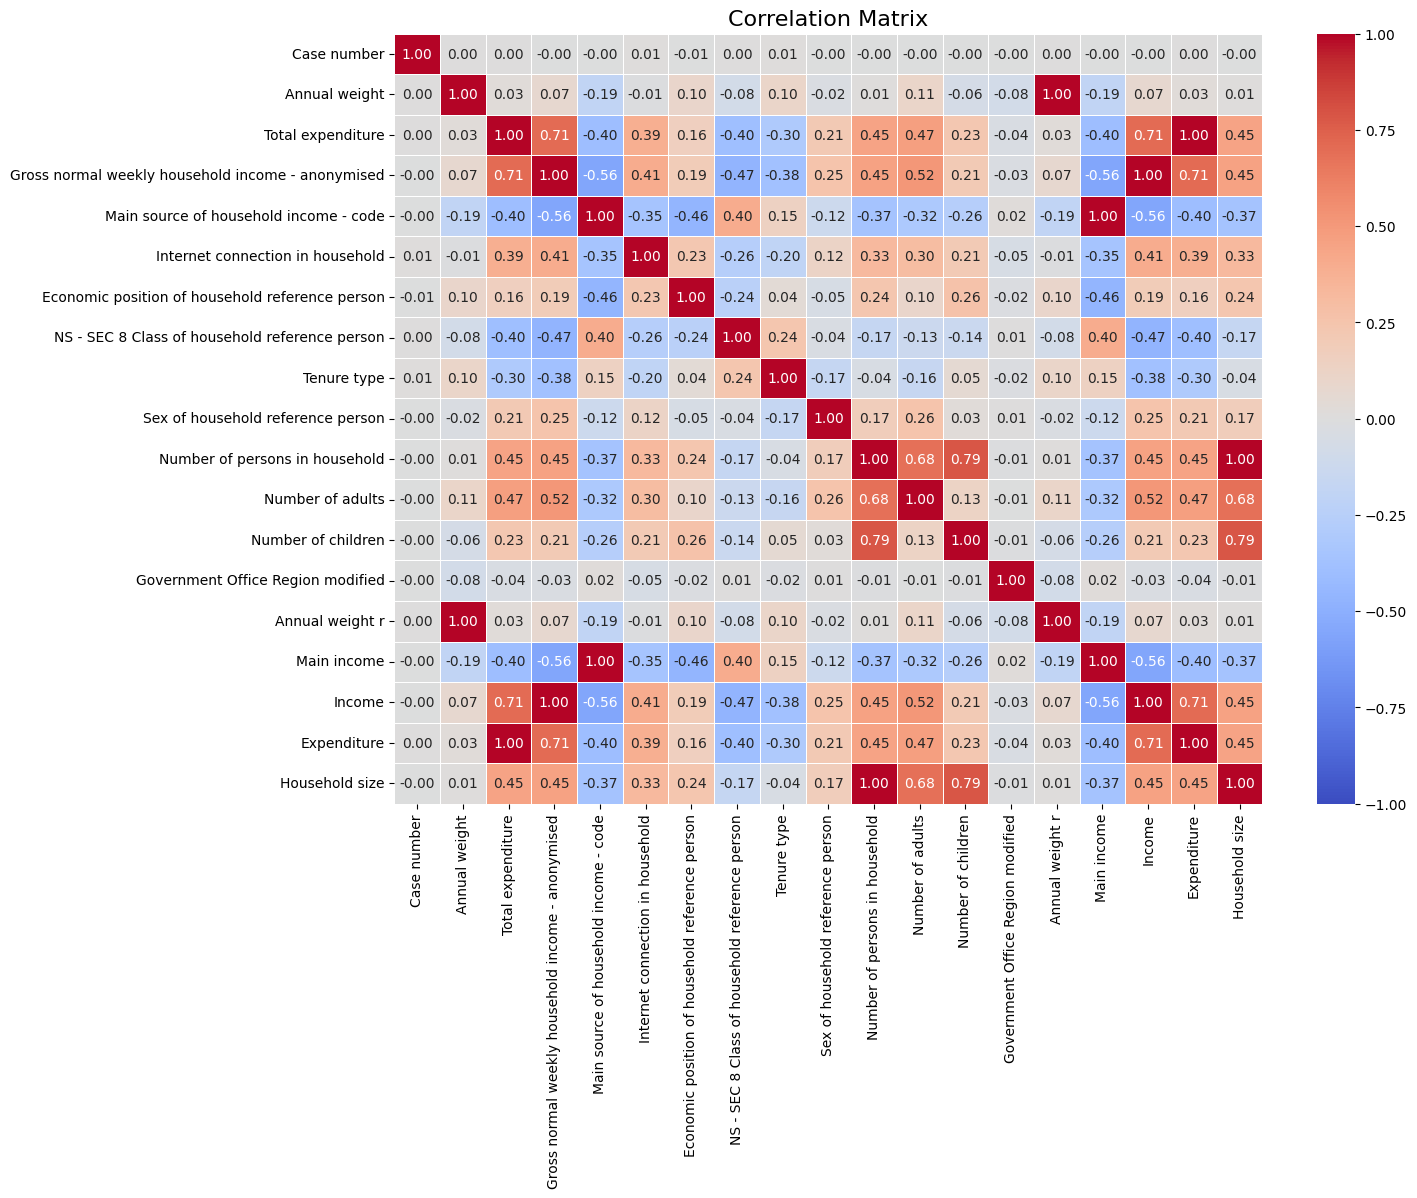

In [3017]:
# Create a correlation matrix heatmap to visualize relationships between features
plt.figure(figsize=(14, 10))

corr_matrix = df_scaled.corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title('Correlation Matrix', fontsize=16)
plt.show()

In [3018]:
# Drop highly correlated and redundant features to reduce multicollinearity
df_columns_to_drop = ['Total expenditure',
                      'Annual weight r',
                      'Gross normal weekly household income - anonymised',
                      'Main source of household income - code',
                      'Number of persons in household']

df_columns = df_scaled.drop(columns=df_columns_to_drop)

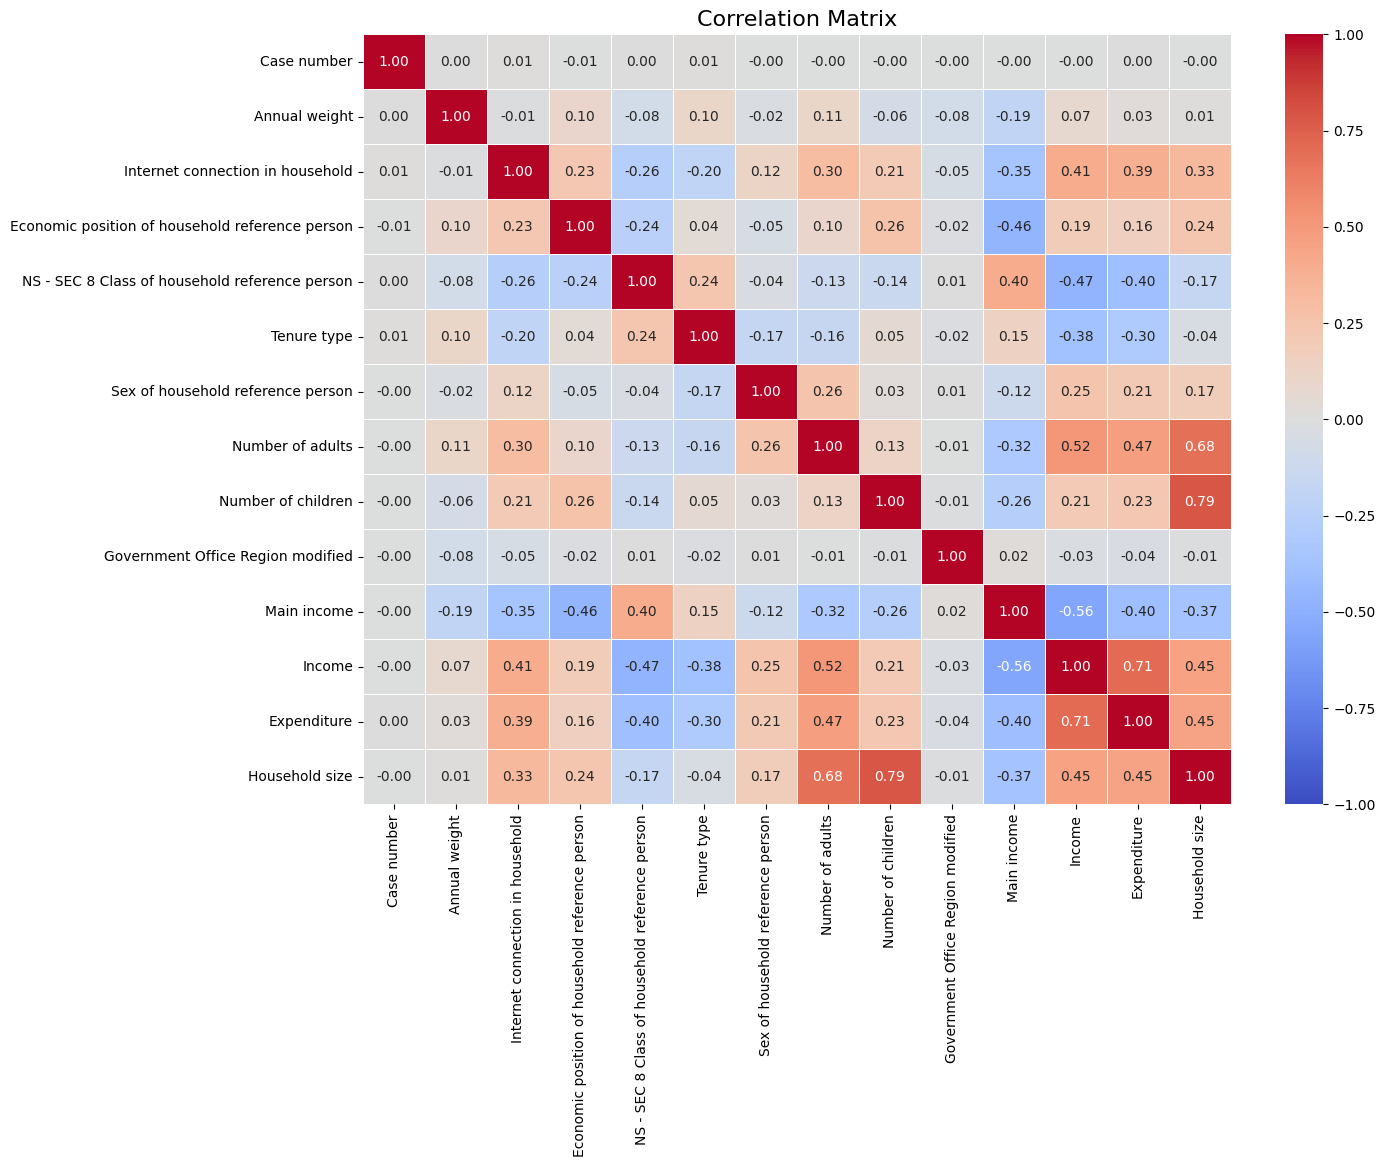

In [3019]:
# Create correlation matrix heatmap for the selected features
plt.figure(figsize=(14, 10))

new_corr_matrix = df_columns.corr()

sns.heatmap(new_corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title('Correlation Matrix', fontsize=16)
plt.show()

In [3020]:
# Rank features by their correlation with the target variable (Expenditure)
print("\nRanking the correlation with 'Expenditure'")
print(new_corr_matrix['Expenditure'].drop('Expenditure').sort_values(ascending=False))


Ranking the correlation with 'Expenditure'
Income                                             0.706449
Number of adults                                   0.473217
Household size                                     0.449369
Internet connection in household                   0.390488
Number of children                                 0.231041
Sex of household reference person                  0.212637
Economic position of household reference person    0.158983
Annual weight                                      0.030384
Case number                                        0.003304
Government Office Region modified                 -0.037357
Tenure type                                       -0.301404
NS - SEC 8 Class of household reference person    -0.397966
Main income                                       -0.403517
Name: Expenditure, dtype: float64


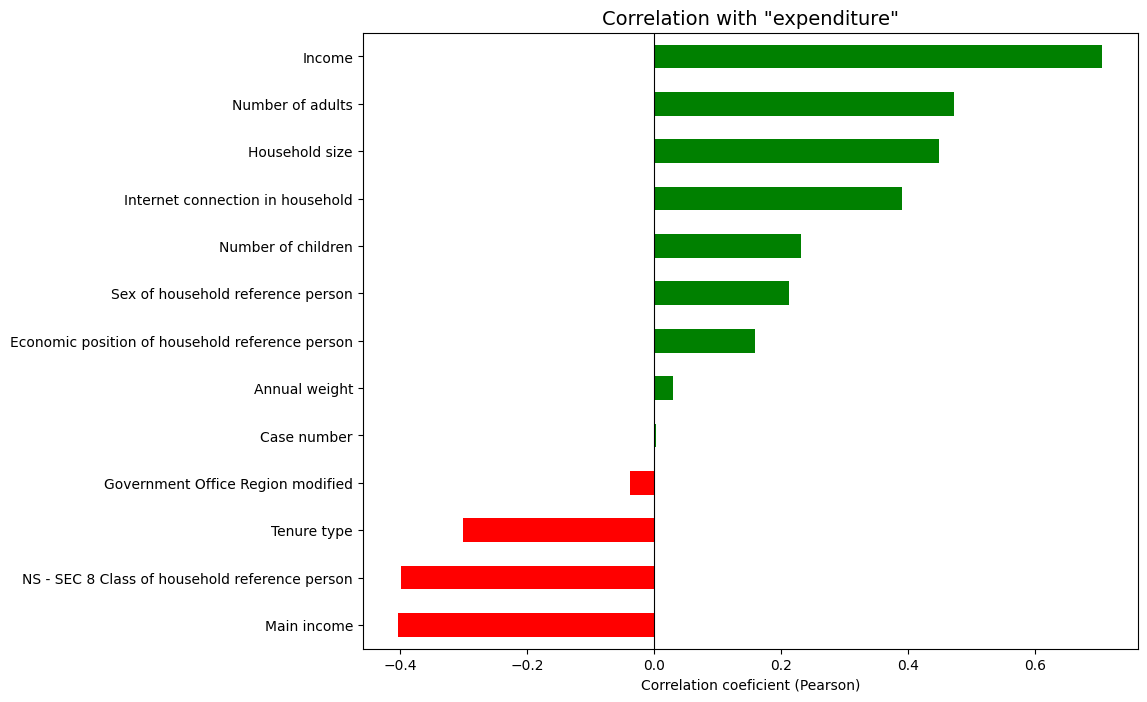

In [3021]:
# Visualize the correlation of each feature with the target variable (Expenditure)
plt.figure(figsize=(10, 8))
corr_target = df_columns.corr()['Expenditure'].drop('Expenditure').sort_values(ascending=True)

colors = ['red' if x < 0 else 'green' for x in corr_target]
corr_target.plot(kind='barh', color=colors)
plt.title('Correlation with "expenditure"', fontsize=14)
plt.xlabel('Correlation coeficient (Pearson)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

## Data Preparation

In [3022]:
# Split data into training and testing sets (80/20 split)
X = df_columns.drop('Expenditure', axis=1)
y = df_columns['Expenditure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Machine Learning Models

### Linear Regression

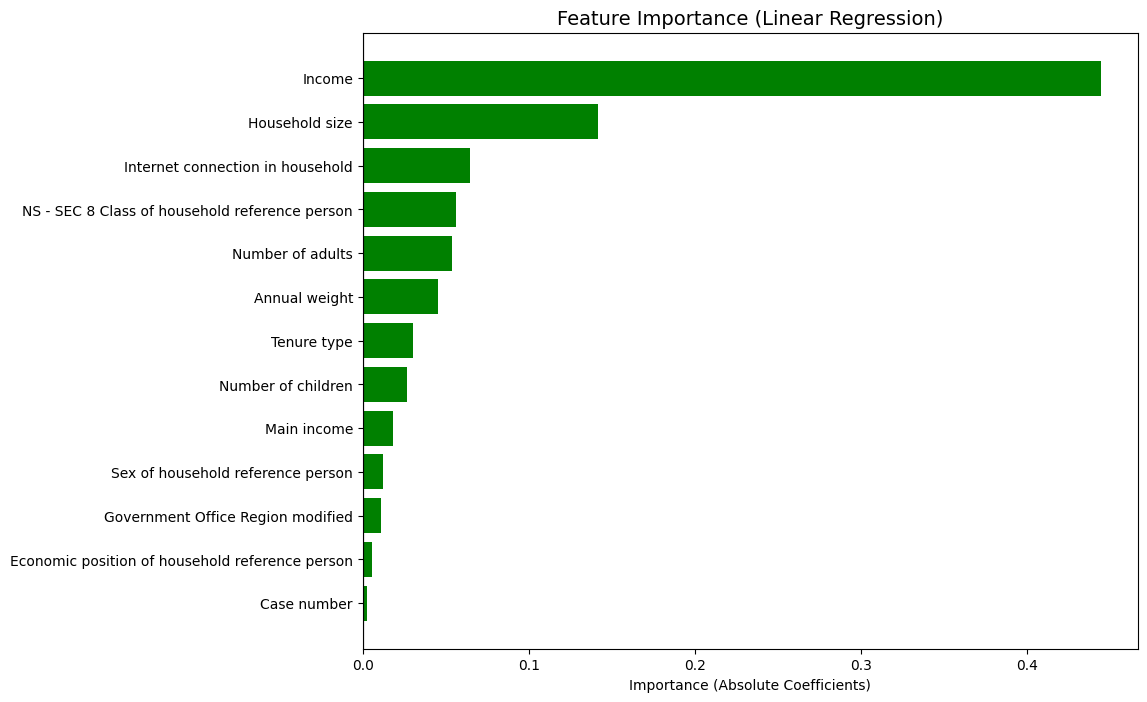

In [3023]:
# Train Linear Regression model and calculate variable importance
lr = LinearRegression()
lr.fit(X_train, y_train)

lin_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": np.abs(lr.coef_)
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(lin_imp['feature'], lin_imp['importance'], color='green')
plt.title('Feature Importance (Linear Regression)', fontsize=14)
plt.xlabel('Importance (Absolute Coefficients)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

In [3024]:
# Dropping the features with very high correlation with the target variable and retraining the model to see if the importance of other features changes significantly
df_final = df_columns.drop(columns=['Income', 'Household size'])

X_1 = df_final.drop('Expenditure', axis=1)
y_1 = df_final['Expenditure']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

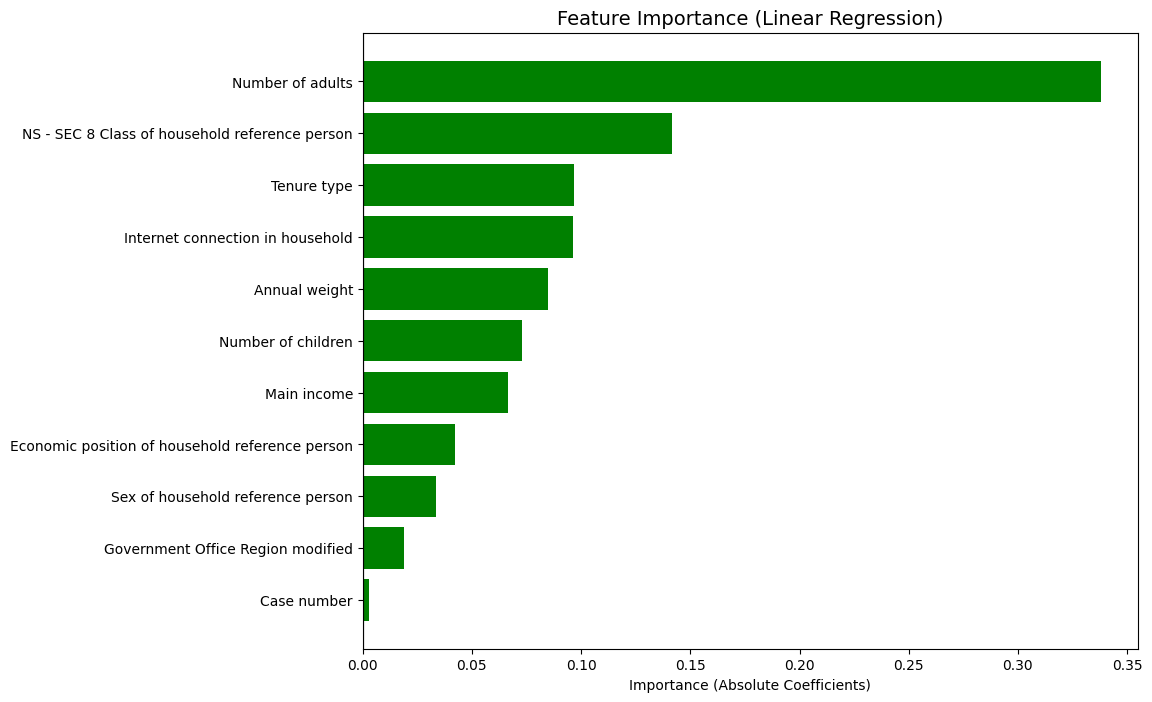

In [3025]:
# Train Linear Regression model and calculate variable importance after dropping highly correlated features
lr = LinearRegression()
lr.fit(X_train_1, y_train_1)

lin_imp = pd.DataFrame({
    "feature": X_train_1.columns,
    "importance": np.abs(lr.coef_)
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(lin_imp['feature'], lin_imp['importance'], color='green')
plt.title('Feature Importance (Linear Regression)', fontsize=14)
plt.xlabel('Importance (Absolute Coefficients)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

### Random Forest

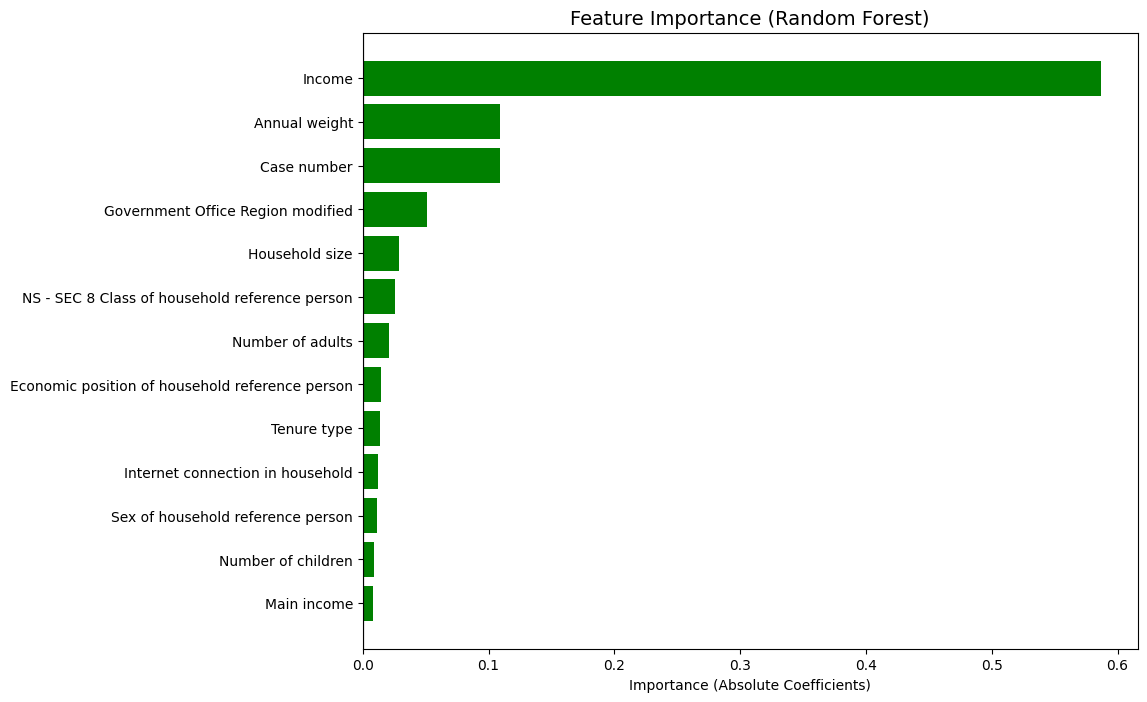

In [3026]:
# Train Random Forest model and calculate variable importance
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(rf_imp['feature'], rf_imp['importance'], color='green')
plt.title('Feature Importance (Random Forest)', fontsize=14)
plt.xlabel('Importance (Absolute Coefficients)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

In [3027]:
# Dropping the features with very high correlation with the target variable and retraining the model to see if the importance of other features changes significantly
df_final = df_columns.drop(columns=['Income', 'Annual weight', 'Case number'])

X_1 = df_final.drop('Expenditure', axis=1)
y_1 = df_final['Expenditure']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

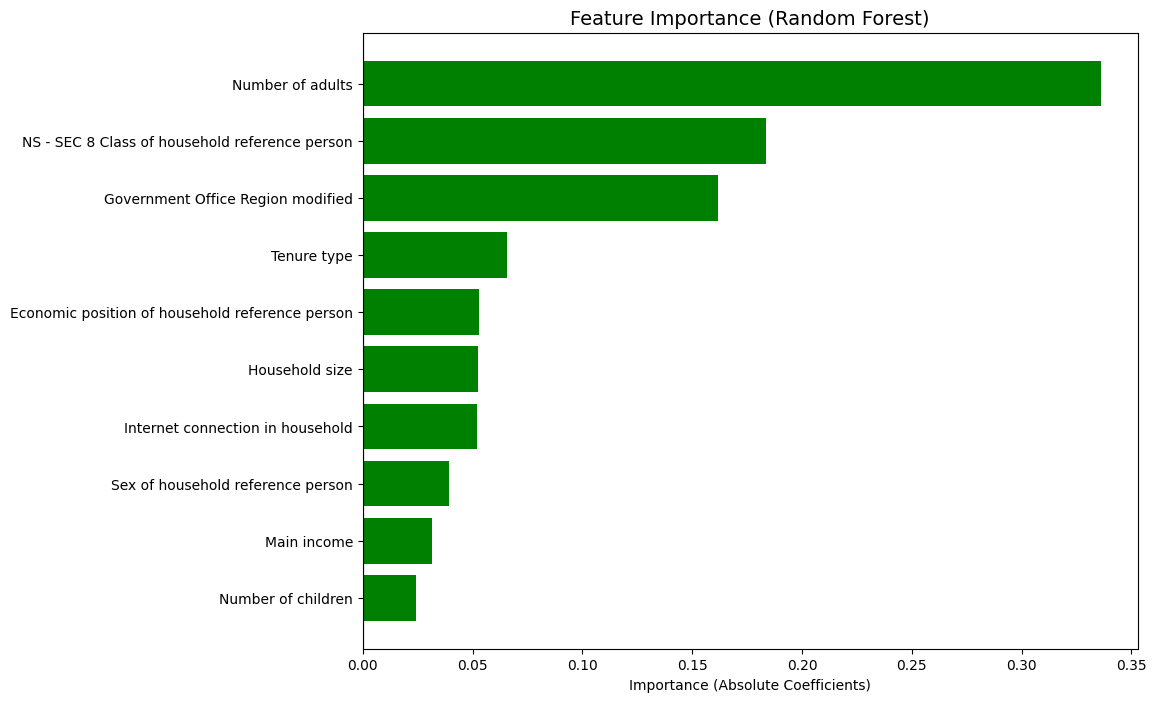

In [3028]:
# Train Random Forest model and calculate variable importance after dropping highly correlated features
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_1, y_train_1)

rf_imp = pd.DataFrame({
    "feature": X_train_1.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(rf_imp['feature'], rf_imp['importance'], color='green')
plt.title('Feature Importance (Random Forest)', fontsize=14)
plt.xlabel('Importance (Absolute Coefficients)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

### XGBoost

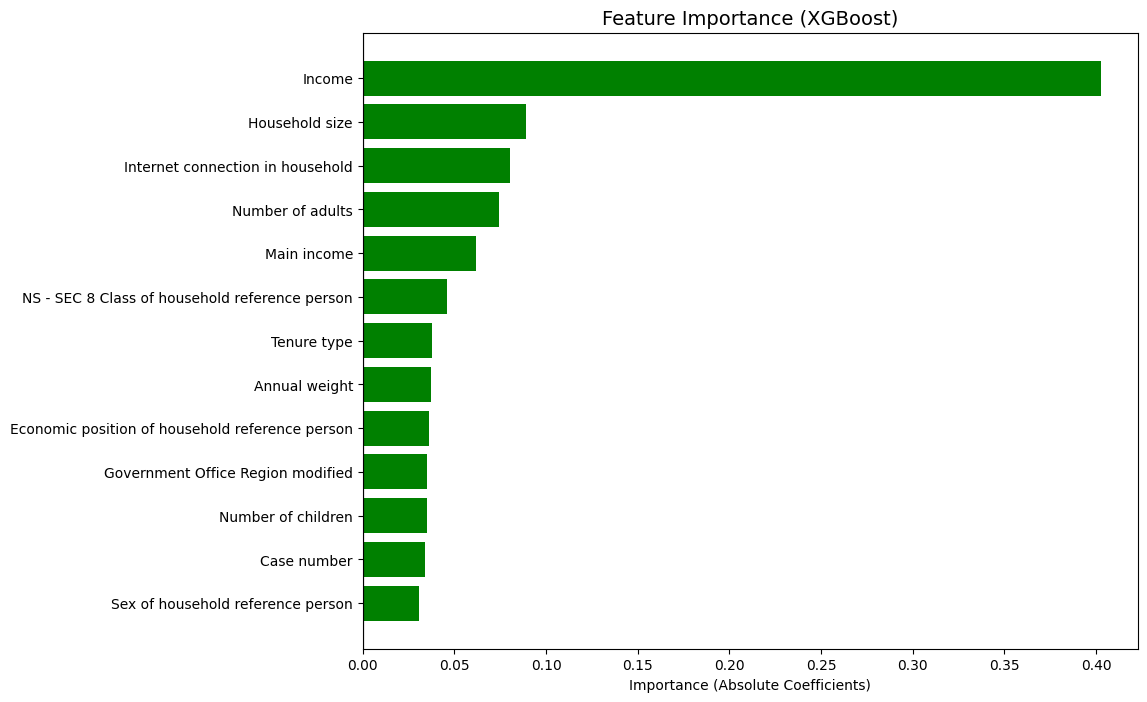

In [3029]:
# Train XGBoost model and calculate variable importance
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)
xgb.fit(X_train, y_train)

xgb_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(xgb_imp['feature'], xgb_imp['importance'], color='green')
plt.title('Feature Importance (XGBoost)', fontsize=14)
plt.xlabel('Importance (Absolute Coefficients)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

In [3030]:
# Dropping the features with very high correlation with the target variable and retraining the model to see if the importance of other features changes significantly
df_final = df_columns.drop(columns=['Income'])

X_1 = df_final.drop('Expenditure', axis=1)
y_1 = df_final['Expenditure']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

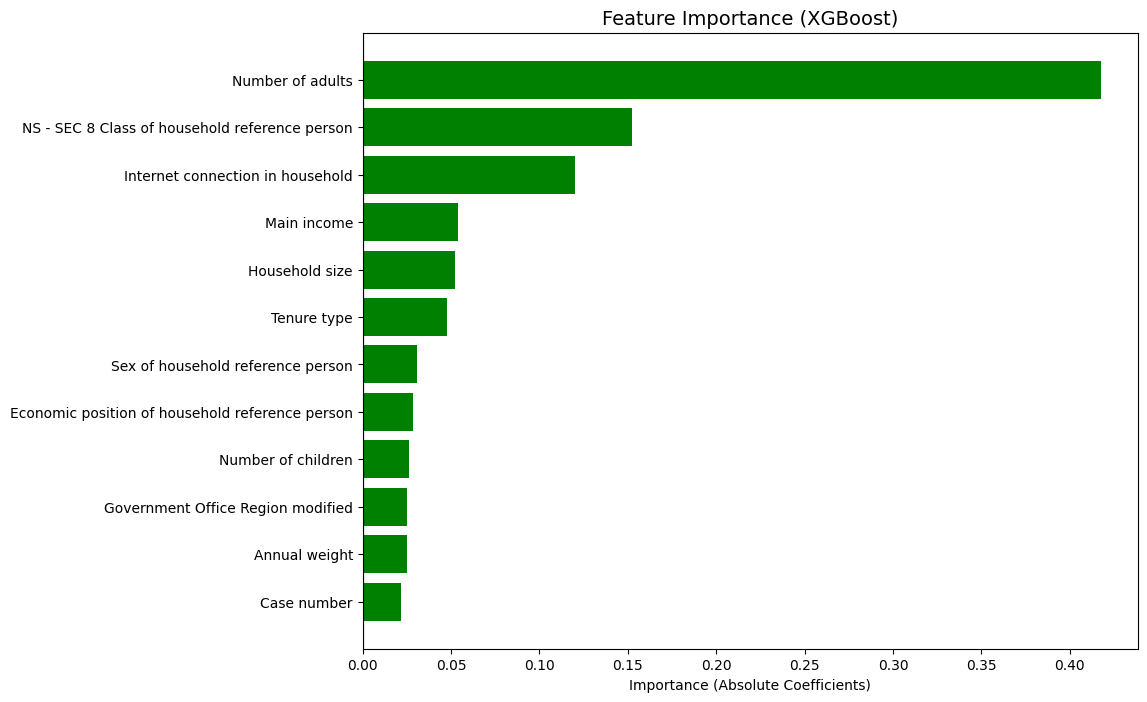

In [3031]:
# Train XGBoost model and calculate variable importance after dropping highly correlated features
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)
xgb.fit(X_train_1, y_train_1)

xgb_imp = pd.DataFrame({
    "feature": X_train_1.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(xgb_imp['feature'], xgb_imp['importance'], color='green')
plt.title('Feature Importance (XGBoost)', fontsize=14)
plt.xlabel('Importance (Absolute Coefficients)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

### CatBoost

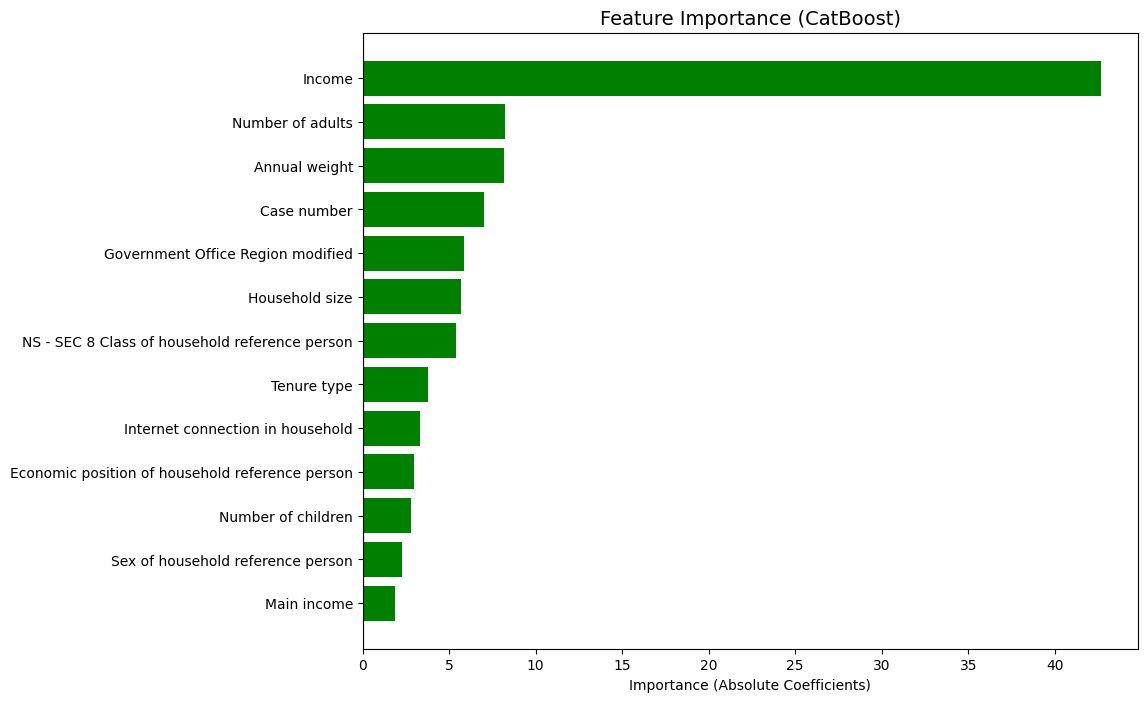

In [3032]:
# Train CatBoost model and calculate variable importance
cb = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    random_seed=42,
    verbose=False
)
cb.fit(X_train, y_train)

cb_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cb.get_feature_importance()
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(cb_imp['feature'], cb_imp['importance'], color='green')
plt.title('Feature Importance (CatBoost)', fontsize=14)
plt.xlabel('Importance (Absolute Coefficients)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

In [3033]:
# Dropping the features with very high correlation with the target variable and retraining the model to see if the importance of other features changes significantly
df_final = df_columns.drop(columns=['Income'])

X_1 = df_final.drop('Expenditure', axis=1)
y_1 = df_final['Expenditure']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

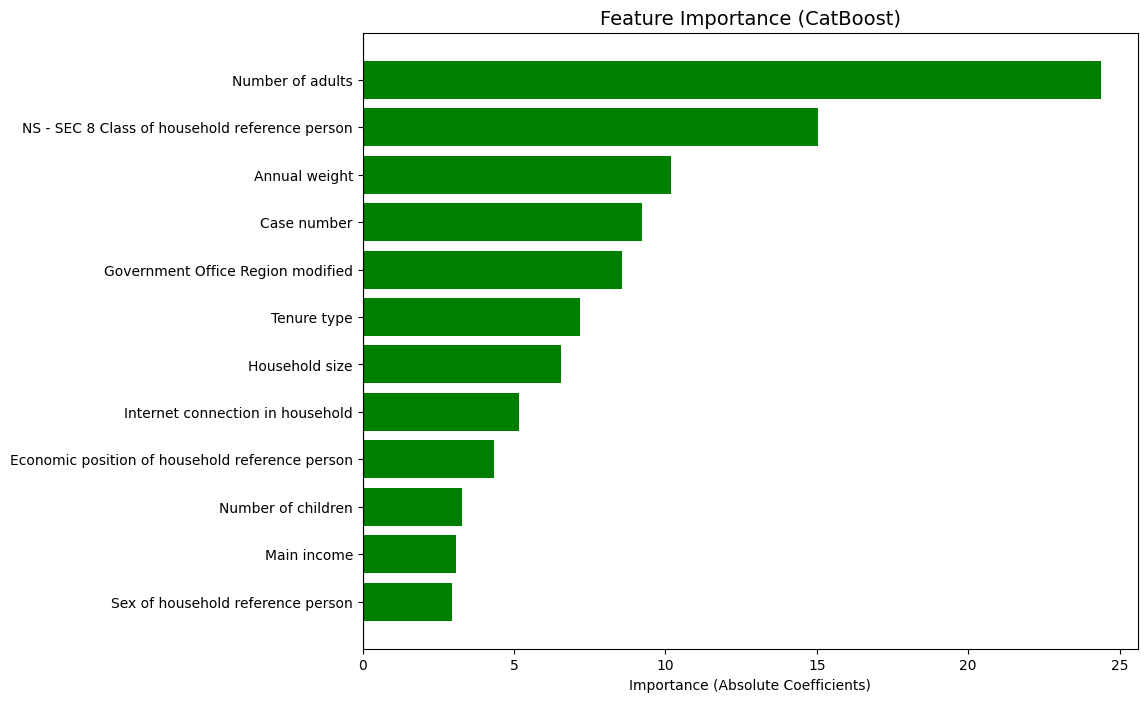

In [3034]:
# Train CatBoost model and calculate variable importance after dropping highly correlated features
cb = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    random_seed=42,
    verbose=False
)
cb.fit(X_train_1, y_train_1)

cb_imp = pd.DataFrame({
    "feature": X_train_1.columns,
    "importance": cb.get_feature_importance()
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(cb_imp['feature'], cb_imp['importance'], color='green')
plt.title('Feature Importance (CatBoost)', fontsize=14)
plt.xlabel('Importance (Absolute Coefficients)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

### Neural Network

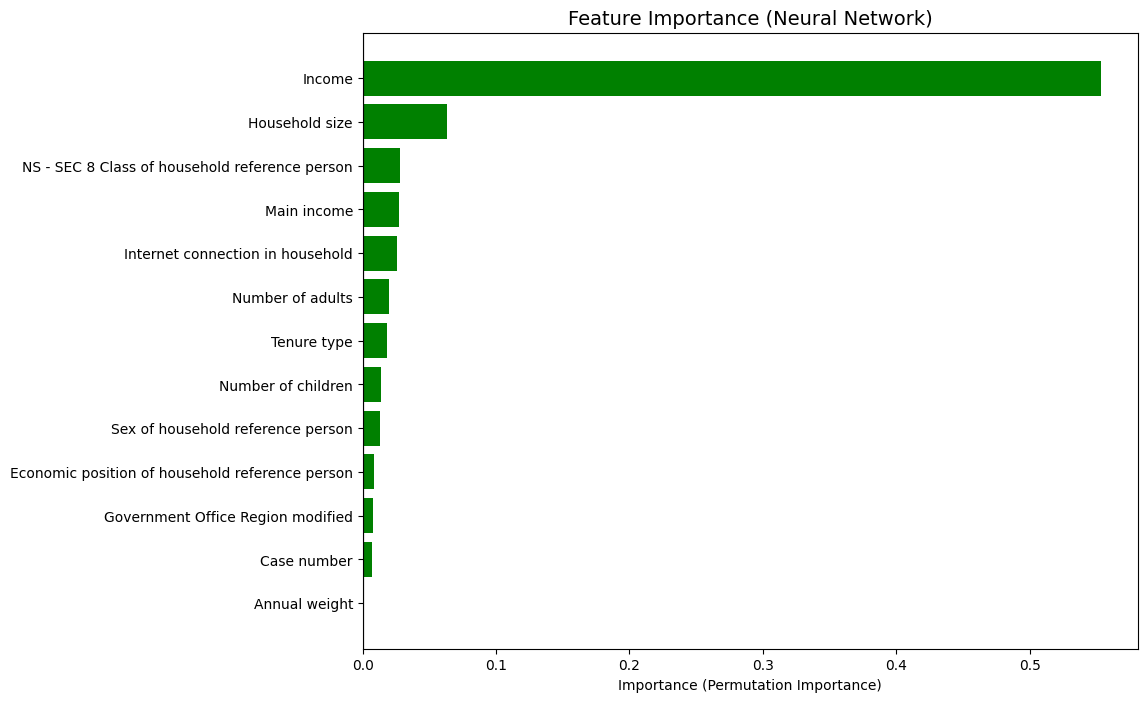

In [3035]:
# Train a Neural Network model and calculate variable importance
nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42
)
nn.fit(X_train, y_train)

r = permutation_importance(
    nn,
    X_train,
    y_train,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": r.importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(perm_imp['feature'], perm_imp['importance'], color='green')
plt.title('Feature Importance (Neural Network)', fontsize=14)
plt.xlabel('Importance (Permutation Importance)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

In [3036]:
# Dropping the features with very high correlation with the target variable and retraining the model to see if the importance of other features changes significantly
df_final = df_columns.drop(columns=['Income', 'Household size'])

X_1 = df_final.drop('Expenditure', axis=1)
y_1 = df_final['Expenditure']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

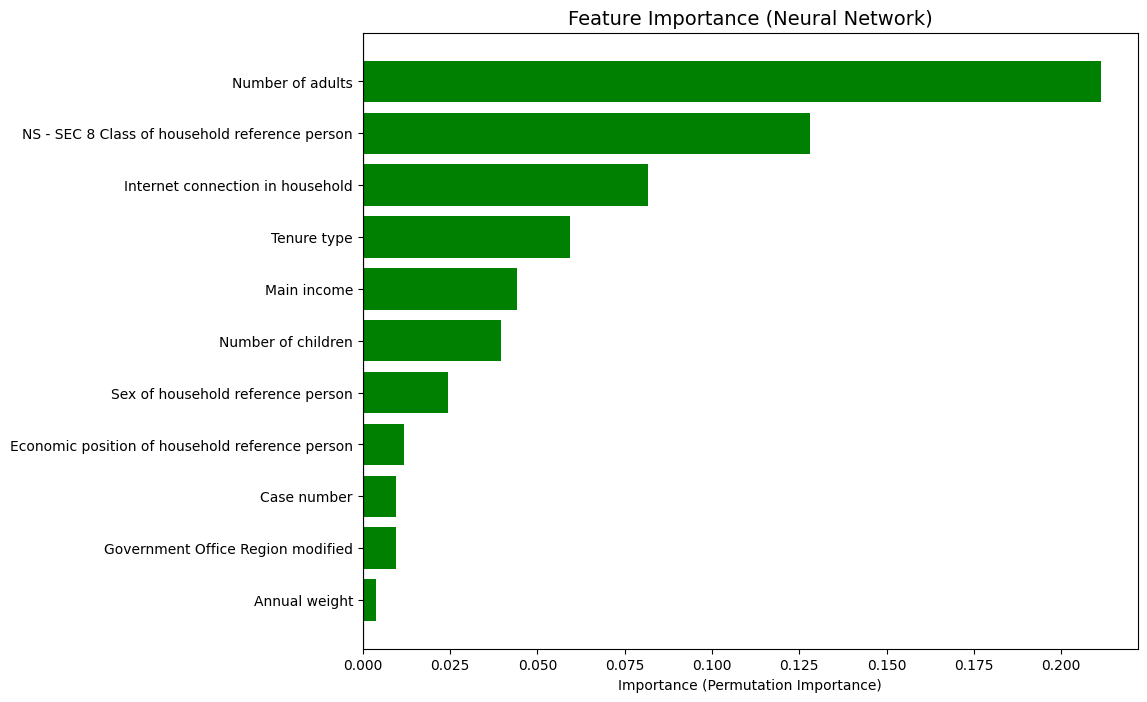

In [3037]:
# Train a Neural Network model and calculate variable importance after dropping highly correlated features
nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42
)
nn.fit(X_train_1, y_train_1)

r = permutation_importance(
    nn,
    X_train_1,
    y_train_1,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    "feature": X_train_1.columns,
    "importance": r.importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(perm_imp['feature'], perm_imp['importance'], color='green')
plt.title('Feature Importance (Neural Network)', fontsize=14)
plt.xlabel('Importance (Permutation Importance)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()